In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")

pd.set_option('display.max_columns', None)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving survey.csv to survey.csv


In [5]:
df = pd.read_csv("survey.csv")
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [10]:
df.shape

(1259, 27)

In [11]:
df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [12]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [13]:
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


In [16]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [17]:
df.isnull().sum().sort_values(ascending=False)

,0
comments,1095
state,515
work_interfere,264
self_employed,18
Gender,0
Timestamp,0
Age,0
family_history,0
treatment,0
no_employees,0


In [18]:
df['Age'].describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [19]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]

In [20]:
df.shape

(1251, 27)

In [21]:
df['Gender'].unique()

array(['Female', 'M', 'Male', 'male', 'female', 'm', 'Male-ish', 'maile',
       'Trans-female', 'Cis Female', 'F', 'something kinda male?',
       'Cis Male', 'Woman', 'f', 'Mal', 'Male (CIS)', 'queer/she/they',
       'non-binary', 'Femake', 'woman', 'Make', 'Nah', 'Enby', 'fluid',
       'Genderqueer', 'Female ', 'Androgyne', 'Agender',
       'cis-female/femme', 'Guy (-ish) ^_^', 'male leaning androgynous',
       'Male ', 'Man', 'Trans woman', 'msle', 'Neuter', 'Female (trans)',
       'queer', 'Female (cis)', 'Mail', 'cis male', 'Malr', 'femail',
       'Cis Man', 'ostensibly male, unsure what that really means'],
      dtype=object)

In [22]:
df['Gender'] = df['Gender'].str.lower().str.strip()

In [23]:
sorted(df['Gender'].unique())

['agender',
 'androgyne',
 'cis female',
 'cis male',
 'cis man',
 'cis-female/femme',
 'enby',
 'f',
 'femail',
 'femake',
 'female',
 'female (cis)',
 'female (trans)',
 'fluid',
 'genderqueer',
 'guy (-ish) ^_^',
 'm',
 'mail',
 'maile',
 'make',
 'mal',
 'male',
 'male (cis)',
 'male leaning androgynous',
 'male-ish',
 'malr',
 'man',
 'msle',
 'nah',
 'neuter',
 'non-binary',
 'ostensibly male, unsure what that really means',
 'queer',
 'queer/she/they',
 'something kinda male?',
 'trans woman',
 'trans-female',
 'woman']

In [24]:
def clean_gender(gender):
    if gender in ['male', 'm', 'man', 'cis male', 'male.', 'mail', 'msle']:
        return 'Male'
    elif gender in ['female', 'f', 'woman', 'cis female', 'female.', 'femake']:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].apply(clean_gender)

In [25]:
df['Gender'].value_counts()

,count
Gender,
Male,976
Female,244
Other,31


In [26]:
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_745/2114044216.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [27]:
numeric_columns = df.select_dtypes(include=['number']).columns

for col in numeric_columns:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_745/2676509655.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [28]:
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,0
self_employed,0
family_history,0
treatment,0
work_interfere,0
no_employees,0


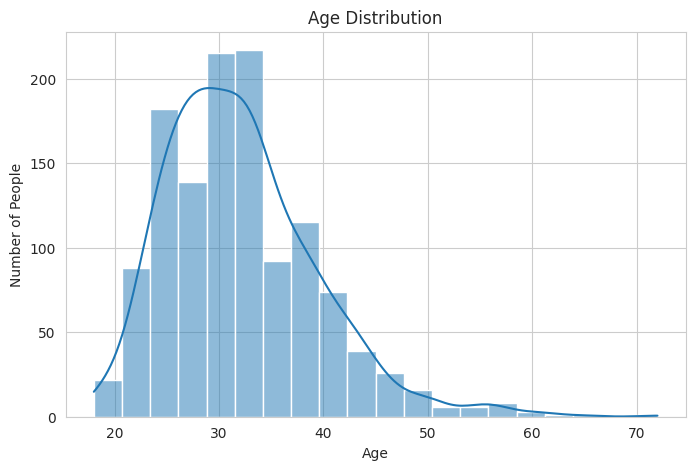

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of People")

plt.show()

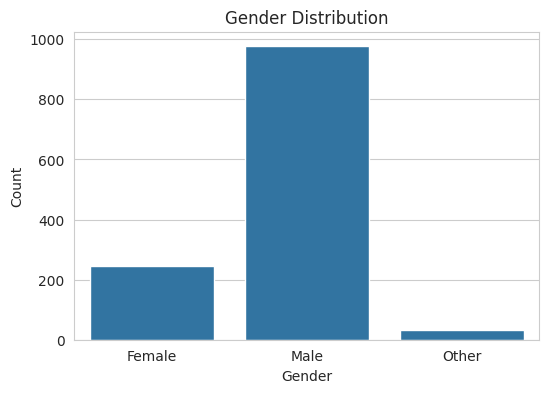

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

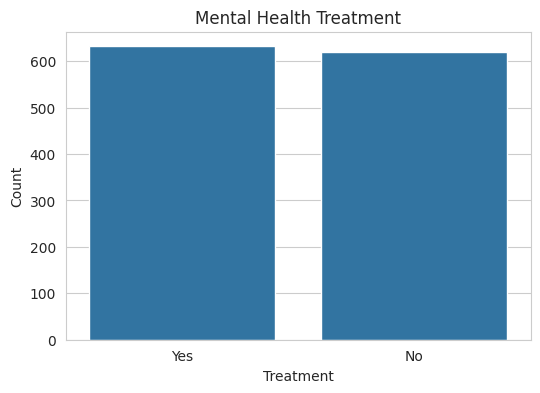

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x='treatment', data=df)

plt.title("Mental Health Treatment")
plt.xlabel("Treatment")
plt.ylabel("Count")

plt.show()

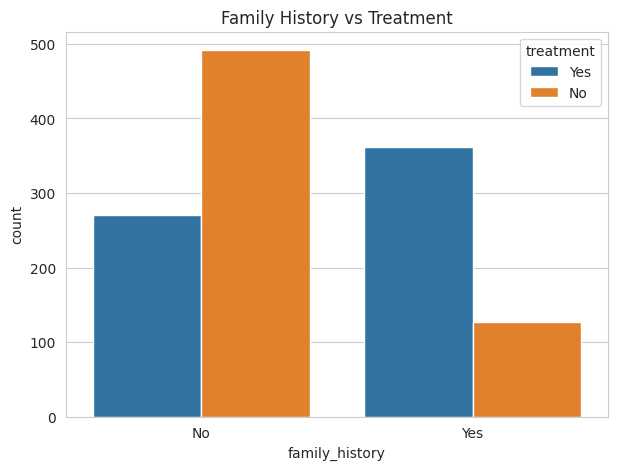

In [32]:
plt.figure(figsize=(7,5))
sns.countplot(x='family_history', hue='treatment', data=df)

plt.title("Family History vs Treatment")

plt.show()

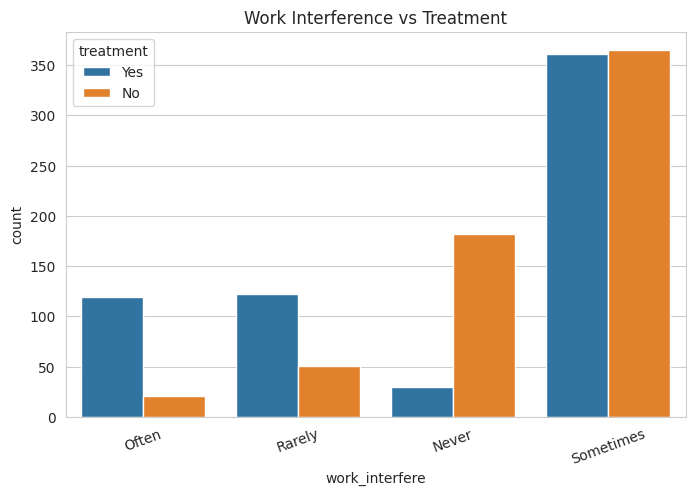

In [33]:
plt.figure(figsize=(8,5))
sns.countplot(x='work_interfere', hue='treatment', data=df)

plt.title("Work Interference vs Treatment")
plt.xticks(rotation=20)

plt.show()

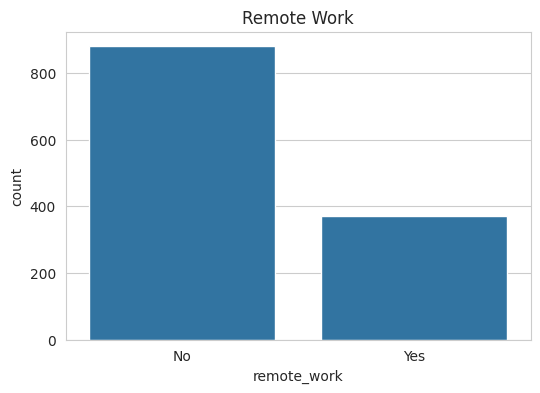

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(x='remote_work', data=df)

plt.title("Remote Work")

plt.show()

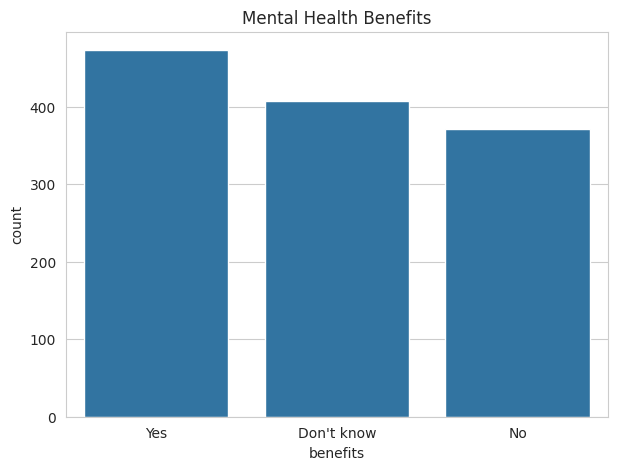

In [35]:
plt.figure(figsize=(7,5))
sns.countplot(x='benefits', data=df)

plt.title("Mental Health Benefits")

plt.show()

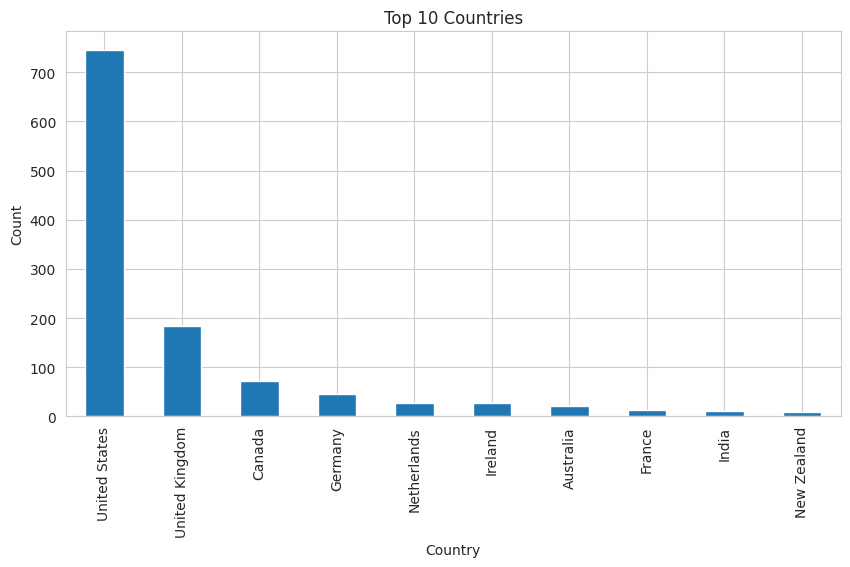

In [36]:
plt.figure(figsize=(10,5))

df['Country'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

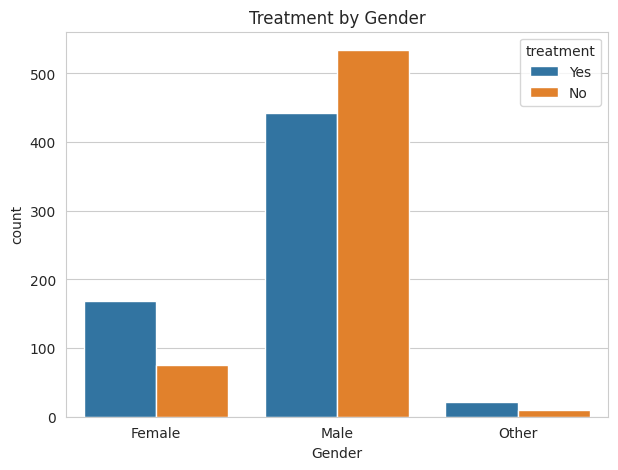

In [37]:
plt.figure(figsize=(7,5))
sns.countplot(x='Gender', hue='treatment', data=df)

plt.title("Treatment by Gender")

plt.show()

In [39]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

encoder = LabelEncoder()

for column in df_encoded.columns:
    if df_encoded[column].dtype == 'object':
        df_encoded[column] = encoder.fit_transform(df_encoded[column].astype(str))

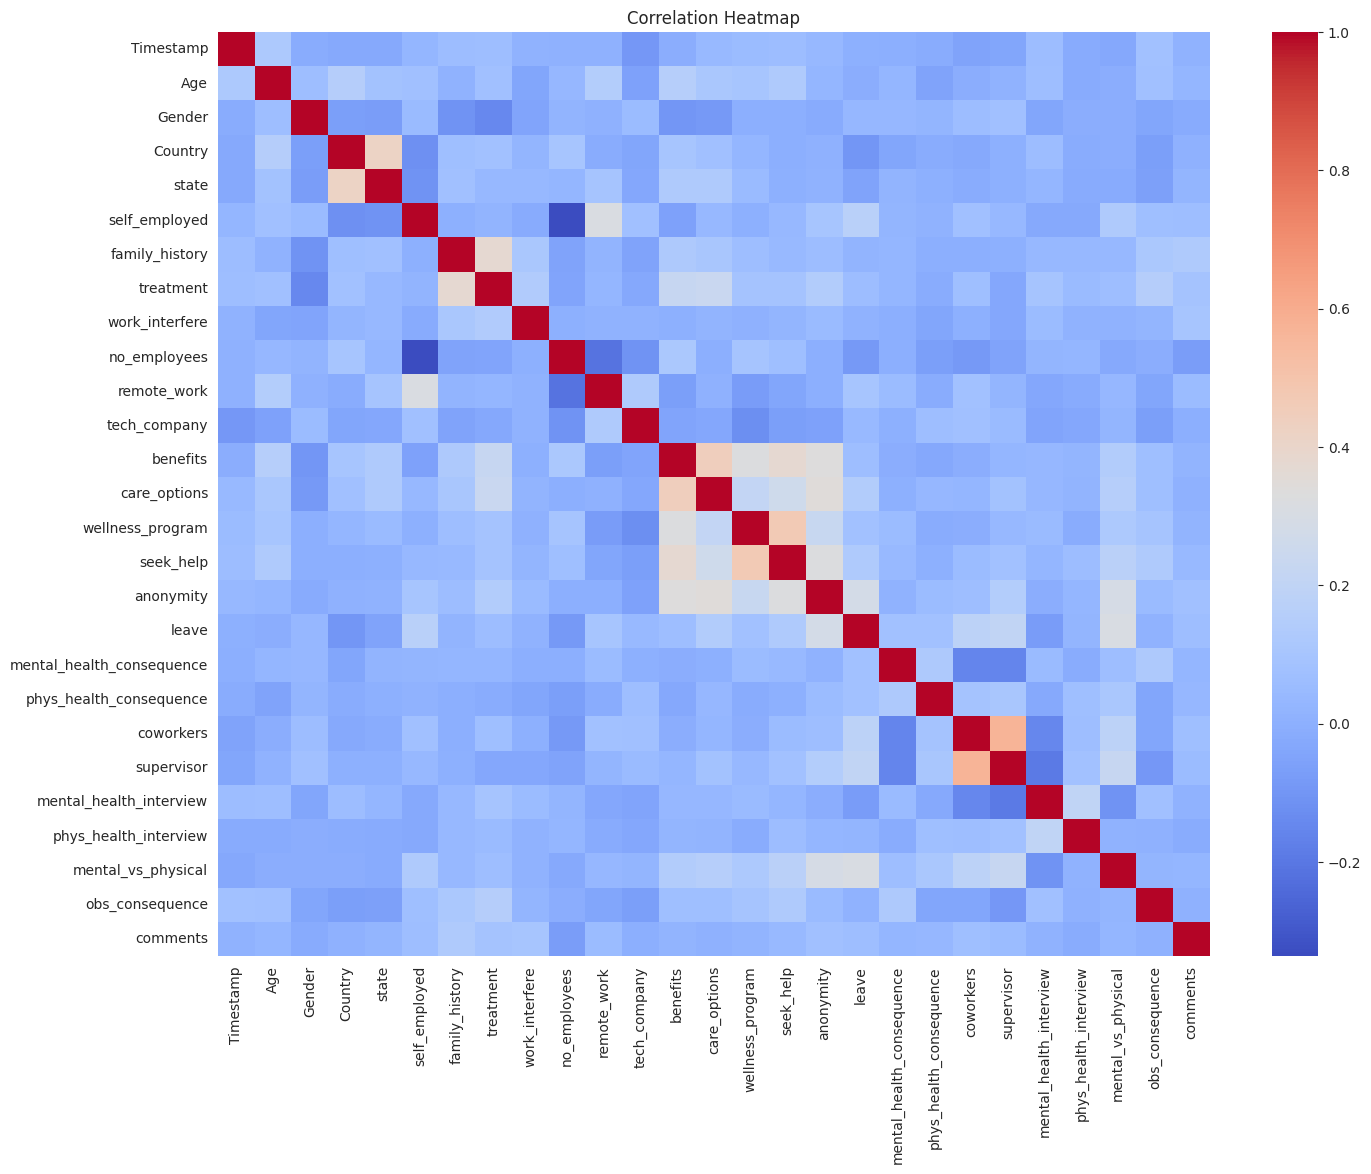

In [40]:
plt.figure(figsize=(16,12))

sns.heatmap(df_encoded.corr(),
            cmap='coolwarm',
            annot=False)

plt.title("Correlation Heatmap")

plt.show()

In [41]:
df_encoded.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [42]:
X = df_encoded.drop("treatment", axis=1)
y = df_encoded["treatment"]

In [43]:
print("Features:", X.shape)
print("Target:", y.shape)

Features: (1251, 26)
Target: (1251,)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
print(X_train.shape)
print(X_test.shape)

(1000, 26)
(251, 26)


In [46]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [47]:
lr_pred = lr.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.6852589641434262


In [49]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [50]:
dt_pred = dt.predict(X_test)

In [51]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.5896414342629482


In [52]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [53]:
rf_pred = rf.predict(X_test)

In [54]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.701195219123506


In [55]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.685259
1,Decision Tree,0.589641
2,Random Forest,0.701195


In [56]:
results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.701195
0,Logistic Regression,0.685259
1,Decision Tree,0.589641


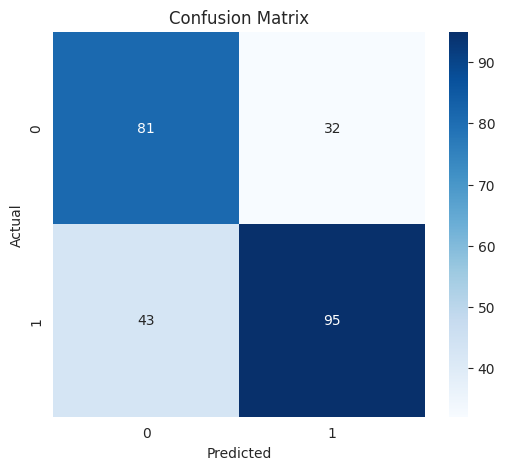

In [57]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.65      0.72      0.68       113
           1       0.75      0.69      0.72       138

    accuracy                           0.70       251
   macro avg       0.70      0.70      0.70       251
weighted avg       0.71      0.70      0.70       251



In [59]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
6,family_history,0.102986
7,work_interfere,0.100195
0,Timestamp,0.094916
1,Age,0.080829
12,care_options,0.061469
3,Country,0.045098
4,state,0.044982
11,benefits,0.044199
8,no_employees,0.041758
16,leave,0.036940


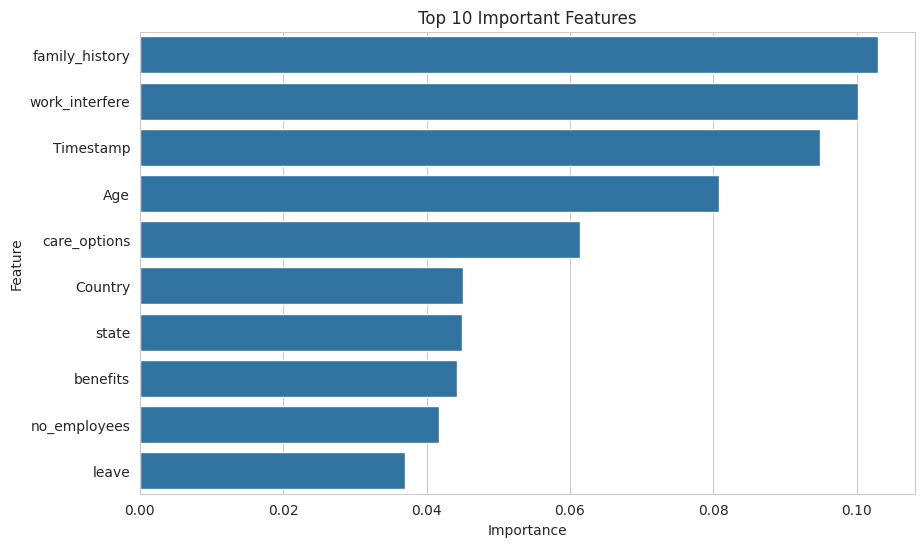

In [60]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

Conclusion :

->Performed data cleaning by handling missing values, duplicate records, and inconsistent gender labels.

->Conducted exploratory data analysis using multiple visualizations.

->Built three machine learning models: Logistic Regression, Decision Tree, and Random Forest.

->Compared model performance using accuracy scores.

->Random Forest achieved the highest accuracy (if that's what your results show).

->Feature importance analysis highlighted the factors that most influenced mental health treatment prediction.

->This project demonstrates how machine learning can support mental health awareness and early intervention.